In [2]:
!pip install shap

In [3]:
import pandas as pd
import numpy as np
import joblib
import shap
import matplotlib.pyplot as plt

c:\Users\Mega Providers\OneDrive\Desktop\CardioLens\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
df = pd.read_csv("../data/raw/heart.csv")

X = df.drop("target", axis=1)
y = df["target"]

X.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2


In [5]:
scaler = joblib.load("../models/scaler.pkl")
model = joblib.load("../models/random_forest_tuned.pkl")

X_scaled = scaler.transform(X)

In [6]:
explainer = shap.TreeExplainer(model)

shap_values = explainer.shap_values(X_scaled)

print(shap_values.shape)

(303, 13, 2)


In [7]:
shap_values_class1 = shap_values[:, :, 1]

print(shap_values_class1.shape)

(303, 13)


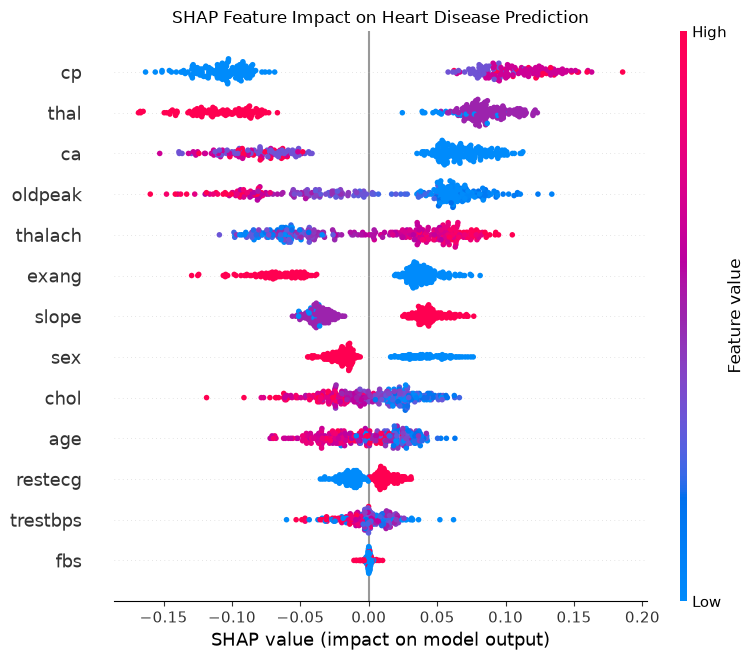

In [8]:
plt.figure()

shap.summary_plot(
    shap_values_class1,
    X,
    feature_names=X.columns,
    show=False
)

plt.title("SHAP Feature Impact on Heart Disease Prediction")
plt.tight_layout()
plt.show()

In [11]:
patient_index = 0

patient = X.iloc[[patient_index]]
patient_scaled = scaler.transform(patient)

prediction = model.predict(patient_scaled)[0]
probability = model.predict_proba(patient_scaled)[0][1]

print("Prediction:", prediction)
print("Heart Disease Probability:", probability)

Prediction: 1
Heart Disease Probability: 0.5949351851851847


In [12]:
patient_shap = shap_values[patient_index, :, 1]

explanation_df = pd.DataFrame({
    "Feature": X.columns,
    "SHAP Value": patient_shap,
    "Patient Value": patient.iloc[0].values
})

explanation_df["Absolute SHAP"] = explanation_df["SHAP Value"].abs()

explanation_df = explanation_df.sort_values(
    "Absolute SHAP",
    ascending=False
)

explanation_df

,Feature,SHAP Value,Patient Value,Absolute SHAP
9,oldpeak,-0.102018,2.3,0.102018
11,ca,0.094313,0.0,0.094313
2,cp,0.093414,3.0,0.093414
12,thal,0.056308,1.0,0.056308
8,exang,0.042380,0.0,0.042380
0,age,-0.036673,63.0,0.036673
10,slope,-0.035937,0.0,0.035937
1,sex,-0.027239,1.0,0.027239
4,chol,0.014583,233.0,0.014583
6,restecg,-0.006602,0.0,0.006602


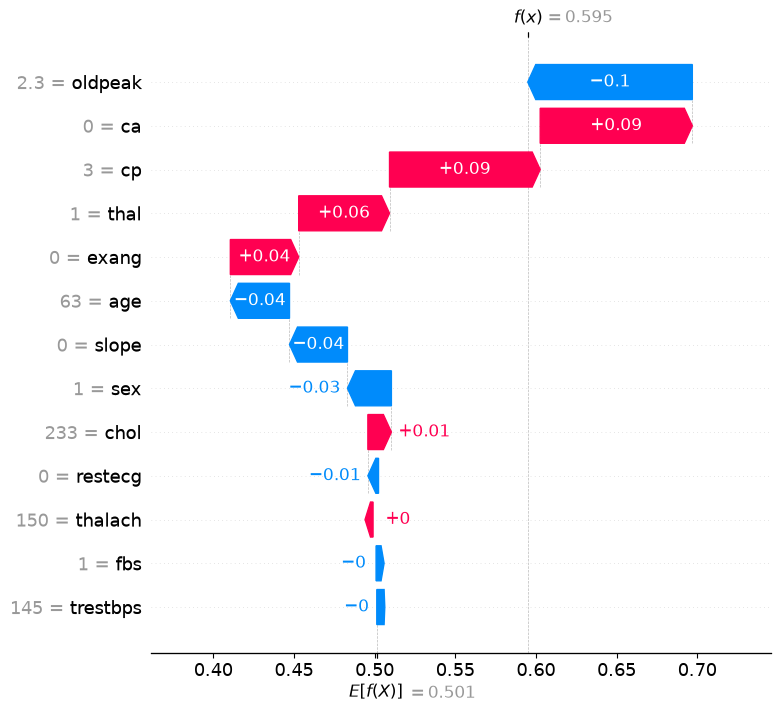

In [ ]:
shap.plots.waterfall(
    shap.Explanation(
        values=patient_shap,
        base_values=explainer.expected_value[1],
        data=patient.iloc[0].values,
        feature_names=X.columns
    ),
    max_display=13
)
